## **On-Policy Distillation & Generalized Knowledge Distillation (GKD) - A Simple Coding Tutorial**

This notebook implements the core ideas from:
> *On-Policy Distillation of Language Models: Learning from Self-Generated Mistakes*  
> Agarwal et al., ICLR 2024

We will build GKD from scratch on a small toy sequence model so every concept runs on CPU in a few minutes.

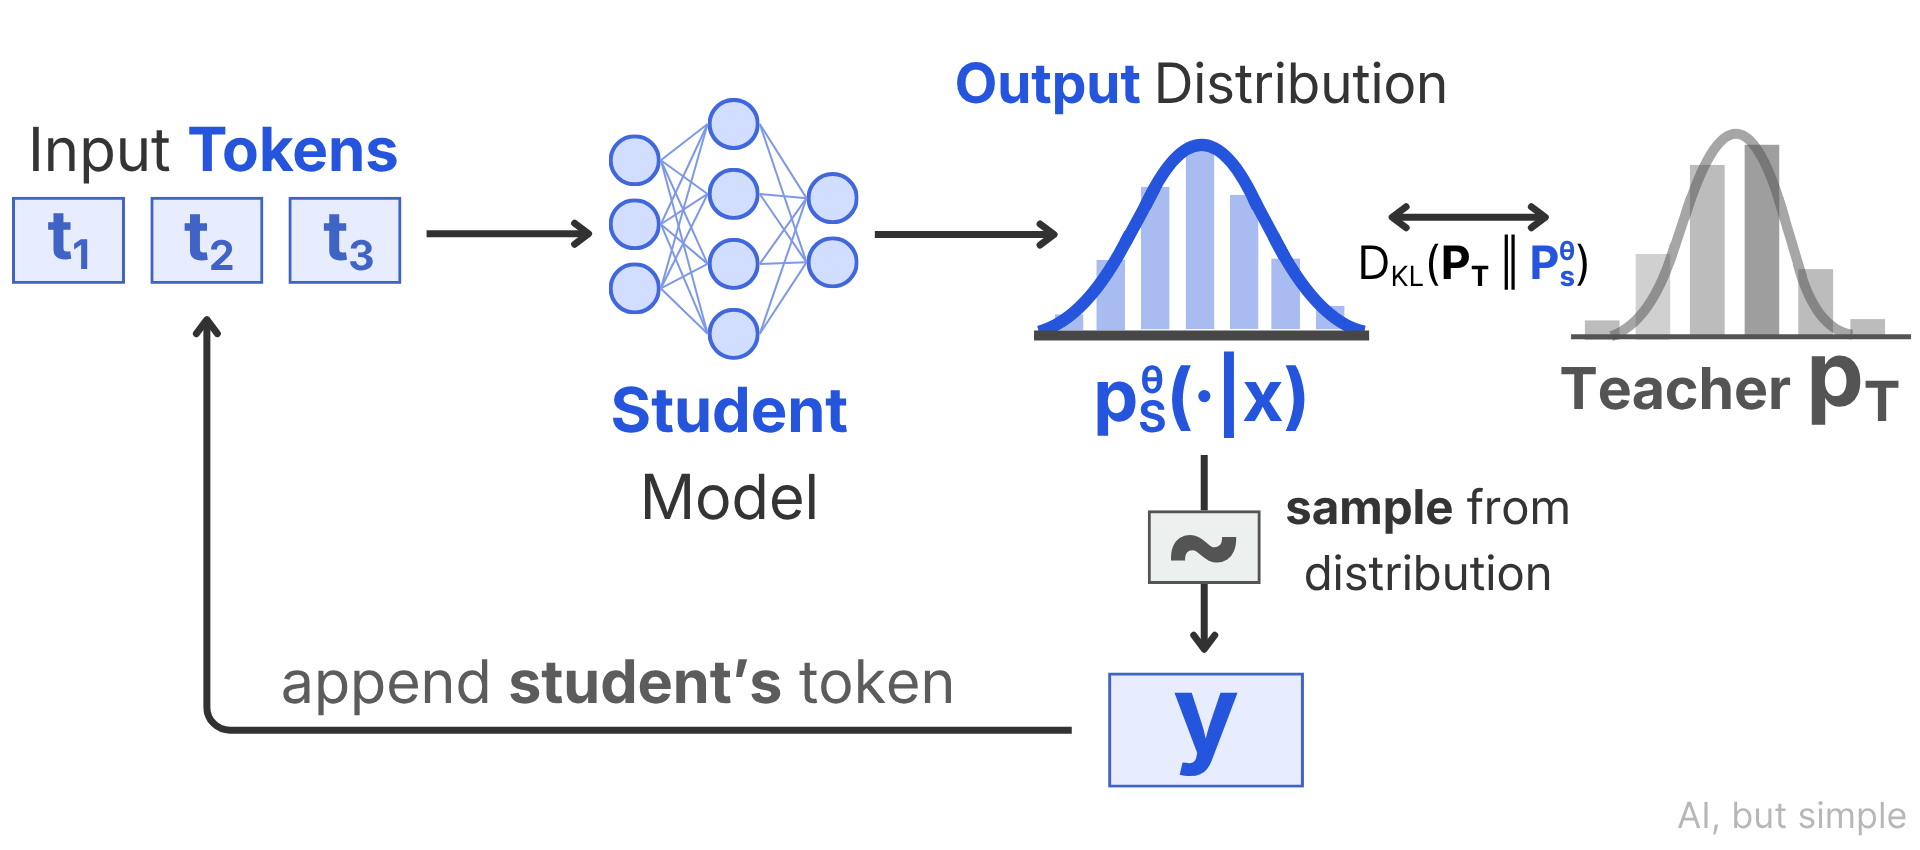

### **What we will build**

| Step | What we implement |
|------|-------------------|
| 1 | A tiny autoregressive teacher and student models (character-level) |
| 2 | Supervised fine-tuning (SFT) baseline |
| 3 | Supervised KD - forward KL on fixed sequences |
| 4 | On-policy GKD - forward KL on student-generated sequences |
| 5 | GKD with reverse KL and JSD divergences |
| 6 | GKD + RL fine-tuning with a simple reward |
| 7 | Comparison of all methods |

Select **GPU** in runtime options for the speed benchmarks. The code will have comments and explanations for clarity. Happy Learning, let's get coding!

—AI, But Simple Team

## **1. Setup and imports**

Let's start by importing our key libraries:
* `torch` for as our main deep learning framework
* `matplotlib` for plots and visualization
* `numpy` for math operations
* `copy`, `random`, `collections` for utilities

Here are the dependencies we should install (if they're not already done yet). Feel free to run this:

```
pip install torch numpy matplotlib
```

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import random
from copy import deepcopy
from collections import defaultdict

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

## **2. Task and Vocabulary**

**Task:** The model learns to generate simple arithmetic expressions like `3+2=5`.

- The **input** is a prompt like `3+2=`
- The **output** is the answer `5` followed by an end token

This is simple enough to train in seconds, but rich enough to show the distillation dynamics clearly.
The teacher will be trained on single-digit sums. We will then distill it into a smaller student.

In [ ]:
# Vocabulary: digits 0-9, operators, special tokens
# Special tokens are multi-character strings kept as atomic entries.
CHARS = list("0123456789+=") + ["<EOS>", "<PAD>"]
# <EOS> = end-of-sequence,  <PAD> = padding

char2idx = {c: i for i, c in enumerate(CHARS)}
idx2char = {i: c for c, i in char2idx.items()}

VOCAB_SIZE = len(CHARS)
EOS_TOKEN = char2idx["<EOS>"]
PAD_TOKEN = char2idx["<PAD>"]

print(f"Vocabulary ({VOCAB_SIZE} tokens):", CHARS)
print(f"EOS index: {EOS_TOKEN},  PAD index: {PAD_TOKEN}")


def encode(s):
    """Encode a string to a list of token indices."""
    return [char2idx[c] for c in s]


def decode(indices):
    """Decode a list of token indices back to a string, skipping special tokens."""
    return "".join(idx2char[i] for i in indices
                   if i not in (PAD_TOKEN, EOS_TOKEN))


def make_dataset(max_val=9):
    """
    Generate all single-digit addition problems.
    Each item is (prompt_ids, target_ids).
      prompt_ids : e.g. encode("3+2=")   -> indices for [3, +, 2, =]
      target_ids : e.g. encode("5") + [EOS_TOKEN]
    """
    data = []
    for a in range(max_val + 1):
        for b in range(max_val + 1):
            result = a + b
            if result > 18:   # keep answers representable as single chars
                continue
            prompt = list(f"{a}+{b}=")          # individual characters
            # result can be 1 or 2 digits; encode each digit separately
            answer_chars = list(str(result))
            prompt_ids = [char2idx[c] for c in prompt]
            target_ids = [char2idx[c] for c in answer_chars] + [EOS_TOKEN]
            data.append((prompt_ids, target_ids))
    return data


dataset = make_dataset()
print(f"\nDataset size: {len(dataset)} examples")
p, t = dataset[5]
print("Example prompt :", decode(p), " -> answer:", decode(t))


## **3. Model Architecture**

We will use a small **LSTM-based autoregressive model**.  
The teacher is larger (hidden size 128), the student is smaller (hidden size 32).  
Both share the same interface so we can swap them in every training loop.

In [ ]:
import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

class TinyLM(nn.Module):
    """
    A small autoregressive character-level language model.
    At each step it reads the current token and produces a
    distribution over the next token.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_TOKEN)
        self.lstm = nn.LSTM(embed_dim, hidden_dim,
                                num_layers=num_layers, batch_first=True)
        self.out_proj = nn.Linear(hidden_dim, vocab_size)

    def forward(self, input_ids, hidden=None):
        """
        input_ids : (batch, seq_len)  token indices
        returns   : logits (batch, seq_len, vocab_size)
        """
        x = self.embed(input_ids)                  # (B, T, E)
        out, hidden = self.lstm(x, hidden)         # (B, T, H)
        logits = self.out_proj(out)                # (B, T, V)
        return logits, hidden

    @torch.no_grad()
    def generate(self, prompt_ids, max_new_tokens=5, temperature=1.0):
        """
        FIX: run the full prompt through the LSTM in one shot to get
        the correct hidden state, then sample one token at a time.

        Previous bug: the last prompt token was run through the LSTM
        a second time, corrupting the hidden state before generation.
        """
        self.eval()
        # Step 1: run the prompt to get the hidden state and initial logits
        inp = torch.tensor([prompt_ids], dtype=torch.long)   # (1, L)
        logits_prompt, hidden = self.forward(inp)            # logits for [p1, p2, a0_pred], hidden after p2

        generated = []

        # If max_new_tokens is 0, return empty.
        if max_new_tokens == 0:
            return generated

        # Get the first prediction (which corresponds to the token after prompt_ids[-1])
        first_gen_logits = logits_prompt[0, -1, :]
        probs = F.softmax(first_gen_logits / max(temperature, 1e-6), dim=-1)

        if temperature < 0.01:   # greedy decode
            token = probs.argmax().item()
        else:
            token = torch.multinomial(probs, 1).item()

        generated.append(token)
        if token == EOS_TOKEN:
            return generated

        # Then, generate remaining tokens one by one
        next_input = torch.tensor([[token]], dtype=torch.long)
        for _ in range(max_new_tokens - 1): # -1 because one token was already generated
            logits, hidden = self.forward(next_input, hidden)
            probs = F.softmax(logits[0, -1] / max(temperature, 1e-6), dim=-1)
            if temperature < 0.01:   # greedy decode
                token = probs.argmax().item()
            else:
                token = torch.multinomial(probs, 1).item()
            generated.append(token)
            if token == EOS_TOKEN:
                break
            next_input = torch.tensor([[token]], dtype=torch.long)

        return generated


# Teacher: larger model
teacher = TinyLM(vocab_size=VOCAB_SIZE, embed_dim=32, hidden_dim=128, num_layers=2).to(DEVICE)

# Student: smaller model
student = TinyLM(vocab_size=VOCAB_SIZE, embed_dim=16, hidden_dim=32,  num_layers=1).to(DEVICE)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Teacher parameters: {count_params(teacher):,}")
print(f"Student parameters: {count_params(student):,}")
print(f"Teacher/student ratio: {count_params(teacher)/count_params(student):.1f}x")

## **4. Divergence Functions**

We explored the use of different divergence funcitons in the main article. GKD lets you plug in any divergence between teacher and student distributions.  
Now, we will implement three: **forward KL**, **reverse KL**, and **JSD($\beta$)**.

All three operate **token by token** and are averaged over the sequence length.

In [ ]:
def forward_kl(teacher_logits, student_logits):
    """
    D_KL(p_T || p_S)  -  mode-covering.

    Forces the student to assign probability mass everywhere
    the teacher does.  Using F.kl_div which expects log-probs
    for the second argument.

    teacher_logits, student_logits : (batch, seq_len, vocab_size)
    returns : scalar loss
    """
    p_T = F.softmax(teacher_logits, dim=-1)          # teacher probs
    log_p_S = F.log_softmax(student_logits, dim=-1)  # student log-probs
    # F.kl_div(input=log_q, target=p) computes sum(p * (log_p - input))
    # which equals D_KL(p_T || p_S)
    loss = F.kl_div(log_p_S, p_T, reduction='batchmean')
    return loss


def reverse_kl(teacher_logits, student_logits):
    """
    D_KL(p_S || p_T)  -  mode-seeking.

    The student ignores low-probability teacher regions.
    Produces sharper, less diverse generations.
    """
    p_S = F.softmax(student_logits, dim=-1)
    log_p_T = F.log_softmax(teacher_logits, dim=-1)
    loss = F.kl_div(log_p_T, p_S, reduction='batchmean')
    return loss


def jsd(teacher_logits, student_logits, beta=0.5):
    """
    Generalized Jensen-Shannon Divergence with parameter beta.

    D_JSD(beta)(P || Q) = beta * D_KL(P || M) + (1-beta) * D_KL(Q || M)
    where M = beta*P + (1-beta)*Q

    beta -> 0 : behaves like forward KL
    beta -> 1 : behaves like reverse KL
    """
    p_T = F.softmax(teacher_logits, dim=-1)
    p_S = F.softmax(student_logits, dim=-1)
    M = beta * p_T + (1.0 - beta) * p_S          # mixture distribution
    log_M = (M + 1e-10).log()

    kl_T = F.kl_div(log_M, p_T, reduction='batchmean')   # D_KL(p_T || M)
    kl_S = F.kl_div(log_M, p_S, reduction='batchmean')   # D_KL(p_S || M)
    return beta * kl_T + (1.0 - beta) * kl_S


# Map divergence names to functions
DIVERGENCES = {
    'forward_kl'  : forward_kl,
    'reverse_kl'  : reverse_kl,
    'jsd_01'      : lambda t, s: jsd(t, s, beta=0.1),
    'jsd_05'      : lambda t, s: jsd(t, s, beta=0.5),
    'jsd_09'      : lambda t, s: jsd(t, s, beta=0.9),
}

print('Divergence functions registered:', list(DIVERGENCES.keys()))

# Quick sanity check
dummy_t = torch.randn(2, 5, VOCAB_SIZE)
dummy_s = torch.randn(2, 5, VOCAB_SIZE)
for name, fn in DIVERGENCES.items():
    val = fn(dummy_t, dummy_s).item()
    print(f'  {name}: {val:.4f}')

## **5. Train the Teacher with Supervised Fine-Tuning**

Before distillation, we need a capable teacher.  
We train it with standard cross-entropy on the ground-truth answers.

This is the same as supervised fine-tuning (SFT) in the paper.

In [ ]:
def make_batch(examples, device=DEVICE):
    """
    Build padded input and target tensors for teacher-forcing training.

    Layout for one example with prompt [p0,p1,p2] and target [a0,a1,EOS]:

      input_ids : [p0, p1, p2, a0, a1, EOS, PAD, ...]
      target_ids : [-100,-100,-100, a0, a1, EOS, -100, ...]

    In compute_nll_loss we shift by 1:
      model input  at pos t = input_ids[t]
      model target at pos t+1 = target_ids[t+1]

    So to predict a0 the model sees p2 as input — correct.
    target_ids is NOT pre-shifted here; the shift happens in the loss.
    """
    full_seqs = [p + t for p, t in examples]
    max_len = max(len(s) for s in full_seqs)

    input_tensor = torch.full((len(examples), max_len), PAD_TOKEN, dtype=torch.long)
    target_tensor = torch.full((len(examples), max_len), -100,      dtype=torch.long)

    for i, (prompt, target) in enumerate(examples):
        seq = prompt + target
        input_tensor[i, :len(seq)] = torch.tensor(seq, dtype=torch.long)
        # Answer tokens start at index len(prompt)
        target_tensor[i, len(prompt):len(seq)] = torch.tensor(target, dtype=torch.long)

    return input_tensor.to(device), target_tensor.to(device)


def compute_nll_loss(model, input_ids, target_ids):
    """
    Standard teacher-forcing cross-entropy loss.

    We predict target[t] from the hidden state produced by input[t-1].
    This is the standard 1-step shift used in all autoregressive LMs.

    FIX: target_ids is aligned with input_ids (not pre-shifted),
    so shifting both by 1 here correctly pairs each input token
    with the target token it should predict next.
    """
    logits, _ = model(input_ids)                       # (B, T, V)
    # input[0..T-2] predicts target[1..T-1]
    logits_in = logits[:, :-1, :].contiguous()        # (B, T-1, V)
    targets_in = target_ids[:, 1:].contiguous()        # (B, T-1)
    loss = F.cross_entropy(
        logits_in.view(-1, VOCAB_SIZE),
        targets_in.view(-1),
        ignore_index=-100
    )
    return loss


def evaluate_accuracy(model, dataset, n_eval=None):
    """
    Greedy decoding accuracy over the dataset.
    A prediction is correct only if every answer token matches exactly.
    """
    model.eval()
    correct = 0
    examples = dataset[:n_eval] if n_eval else dataset
    with torch.no_grad():
        for prompt_ids, target_ids in examples:
            gen = model.generate(prompt_ids, max_new_tokens=5, temperature=0.0)
            pred = [t for t in gen        if t != EOS_TOKEN]
            true = [t for t in target_ids if t != EOS_TOKEN]
            if pred == true:
                correct += 1
    return correct / len(examples)


print("Training utilities ready.")

# Sanity check: overfit a single batch to confirm loss/generate are aligned
_mini = dataset[:8]
_probe = TinyLM(VOCAB_SIZE, 16, 64, 1)
_opt  = torch.optim.Adam(_probe.parameters(), lr=1e-2)
for _step in range(300):
    _probe.train()
    _inp, _tgt = make_batch(_mini)
    _opt.zero_grad()
    compute_nll_loss(_probe, _inp, _tgt).backward()
    _opt.step()
_acc = evaluate_accuracy(_probe, _mini)
assert _acc > 0.9, f"Sanity check failed: overfit acc={_acc:.0%} — check make_batch/loss/generate"
print(f"Sanity check passed: overfit acc = {_acc:.0%} (should be ~100%)")
del _mini, _probe, _opt, _acc


In [ ]:
def train_sft(model, dataset, lr=3e-3, epochs=40, batch_size=16, label='model'):
    """
    Supervised fine-tuning loop.
    Standard cross-entropy on ground-truth target sequences.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []

    for epoch in range(epochs):
        model.train()
        random.shuffle(dataset)
        epoch_loss = 0.0
        n_batches = 0

        for i in range(0, len(dataset), batch_size):
            batch = dataset[i:i + batch_size]
            input_ids, target_ids = make_batch(batch)

            optimizer.zero_grad()
            loss = compute_nll_loss(model, input_ids, target_ids)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1

        avg_loss = epoch_loss / n_batches
        history.append(avg_loss)

        if (epoch + 1) % 10 == 0:
            acc = evaluate_accuracy(model, dataset)
            print(f'[{label}] epoch {epoch+1:3d} | loss {avg_loss:.4f} | acc {acc:.2%}')

    return history


print('Training teacher...')
teacher_history = train_sft(teacher, dataset, lr=3e-3, epochs=120, label='teacher')
teacher_acc = evaluate_accuracy(teacher, dataset)
print(f'\nFinal teacher accuracy: {teacher_acc:.2%}')

## **6. Baseline: SFT student**

We first train the student with pure supervised fine-tuning on the ground-truth data.  
This is the **baseline** every distillation method will be compared against.

Because the student is smaller, it should plateau below the teacher.

In [ ]:
# We will train multiple students and compare them.
# Store a fresh copy of the initial random weights to restart from.
student_init_state = deepcopy(student.state_dict())
results = {}   # method_name -> accuracy

def fresh_student():
    """Return a student model reset to the original random initialisation."""
    s = TinyLM(vocab_size=VOCAB_SIZE, embed_dim=16, hidden_dim=32, num_layers=1).to(DEVICE)
    s.load_state_dict(student_init_state)
    return s


# --- Baseline: SFT ---
student_sft = fresh_student()
print('Training student (SFT baseline)...')
train_sft(student_sft, dataset, lr=3e-3, epochs=120, label='student-SFT')
results['SFT (student baseline)'] = evaluate_accuracy(student_sft, dataset)
print(f"\nSFT student accuracy: {results['SFT (student baseline)']:.2%}")

## 7. **Supervised KD ($\lambda$ = 0)**

The classic knowledge distillation approach.  
The student minimises the **forward KL** against the teacher on the **fixed ground-truth sequences**.

This is GKD with $\lambda$ = 0 (no on-policy data).  
The distribution mismatch problem is still present because the sequences come from the fixed dataset.

In [ ]:
def train_supervised_kd(student, teacher, dataset,
                        divergence_fn=forward_kl,
                        lr=3e-3, epochs=120, batch_size=16, label="supervised-KD"):
    """
    Supervised Knowledge Distillation — GKD with lambda=0.

    At each step:
      1. Sample a batch from the fixed dataset.
      2. Run teacher and student over the full sequence.
      3. Shift logits left by 1 (same as NLL loss) so logit[t]
         predicts token[t+1], then apply divergence on answer positions.
    """
    optimizer = torch.optim.Adam(student.parameters(), lr=lr)
    history = []
    teacher.eval()

    for epoch in range(epochs):
        student.train()
        random.shuffle(dataset)
        epoch_loss = 0.0
        n_batches = 0

        for i in range(0, len(dataset), batch_size):
            batch = dataset[i:i + batch_size]
            input_ids, target_ids = make_batch(batch)

            with torch.no_grad():
                teacher_logits, _ = teacher(input_ids)   # (B, T, V)

            optimizer.zero_grad()
            student_logits, _ = student(input_ids)       # (B, T, V)

            # Shift left by 1: logit at position t predicts token t+1
            # This matches compute_nll_loss exactly.
            t_logits = teacher_logits[:, :-1, :].contiguous()  # (B, T-1, V)
            s_logits = student_logits[:, :-1, :].contiguous()  # (B, T-1, V)
            tgt_shift = target_ids[:, 1:].contiguous()         # (B, T-1)

            # Mask: positions where the shifted target is a real answer token
            mask = (tgt_shift != -100)   # (B, T-1)
            if mask.sum() == 0:
                continue

            t_masked = t_logits[mask]   # (N, V)
            s_masked = s_logits[mask]   # (N, V)

            loss = divergence_fn(
                t_masked.unsqueeze(0).unsqueeze(0),
                s_masked.unsqueeze(0).unsqueeze(0)
            )

            loss.backward()
            torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)
            optimizer.step()

            epoch_loss += loss.item()
            n_batches  += 1

        avg_loss = epoch_loss / max(n_batches, 1)
        history.append(avg_loss)
        if (epoch + 1) % 20 == 0:
            acc = evaluate_accuracy(student, dataset)
            print(f"[{label}] epoch {epoch+1:3d} | loss {avg_loss:.4f} | acc {acc:.2%}")

    return history


student_supkd = fresh_student()
print("Training student (Supervised KD)...")
train_supervised_kd(student_supkd, teacher, dataset, label="supervised-KD")
results["Supervised KD (λ=0)"] = evaluate_accuracy(student_supkd, dataset)
print(f"Supervised KD accuracy: {results['Supervised KD (λ=0)']:.2%}")


## **8. On-policy GKD ($\lambda$ = 1)**

This is the core contribution of the paper.

Instead of training on fixed sequences, the student:
1. **Generates its own output sequences** given the input prompts
2. **Queries the teacher** for token-level distributions on those self-generated sequences
3. **Minimises the divergence** between the teacher and student on those positions

The student now trains on exactly the distribution it will encounter at inference.  
Errors it makes during generation become the training signal for correction.

> **Note on the gradient:** We do NOT backpropagate through the sampling step.  
> The sampled sequence `y` is treated as fixed data. Only the token-level logits  
> get gradients. This is what makes the training stable and efficient.

In [ ]:
def student_generate_batch(student, prompt_batch, max_new_tokens=5, temperature=1.0):
    """
    Generate output sequences from the student for a list of prompts.
    Returns list of (prompt_ids, generated_ids) pairs.
    Generation uses no_grad, no backprop through sampling.
    """
    student.eval()
    generated_batch = []
    with torch.no_grad():
        for prompt_ids in prompt_batch:
            gen = student.generate(prompt_ids, max_new_tokens=max_new_tokens,
                                   temperature=temperature)
            if not gen:
                gen = [EOS_TOKEN]
            if gen[-1] != EOS_TOKEN:
                gen.append(EOS_TOKEN)
            generated_batch.append((prompt_ids, gen))
    return generated_batch


def train_onpolicy_gkd(student, teacher, dataset,
                       divergence_fn=forward_kl,
                       lam=1.0,
                       temperature=1.0,
                       lr=3e-3, epochs=120, batch_size=16, label="on-policy GKD"):
    """
    Generalized Knowledge Distillation, Algorithm 1 from the paper.

    Each step:
      - With prob lambda   : use student-generated sequences (on-policy)
      - With prob 1-lambda : use fixed ground-truth sequences (supervised)
    Then apply divergence(teacher, student) on answer positions.

    lambda=1.0  -> pure on-policy GKD
    lambda=0.0  -> supervised KD
    """
    optimizer = torch.optim.Adam(student.parameters(), lr=lr)
    history = []
    teacher.eval()

    for epoch in range(epochs):
        student.train()
        random.shuffle(dataset)
        epoch_loss = 0.0
        n_batches  = 0

        for i in range(0, len(dataset), batch_size):
            batch_data = dataset[i:i + batch_size]
            batch_prompts = [p for p, t in batch_data]

            # Algorithm 1: coin flip decides data source
            if random.random() <= lam:
                batch = student_generate_batch(
                    student, batch_prompts,
                    max_new_tokens=5, temperature=temperature
                )
            else:
                batch = batch_data

            input_ids, target_ids = make_batch(batch)

            with torch.no_grad():
                teacher_logits, _ = teacher(input_ids)   # (B, T, V)

            student.train()
            optimizer.zero_grad()
            student_logits, _ = student(input_ids)       # (B, T, V)

            # Shift left by 1: logit[t] predicts token[t+1]
            t_logits  = teacher_logits[:, :-1, :].contiguous()
            s_logits  = student_logits[:, :-1, :].contiguous()
            tgt_shift = target_ids[:, 1:].contiguous()

            mask = (tgt_shift != -100)
            if mask.sum() == 0:
                continue

            t_masked = t_logits[mask]   # (N, V)
            s_masked = s_logits[mask]   # (N, V)

            loss = divergence_fn(
                t_masked.unsqueeze(0).unsqueeze(0),
                s_masked.unsqueeze(0).unsqueeze(0)
            )

            loss.backward()
            torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)
            optimizer.step()

            epoch_loss += loss.item()
            n_batches  += 1

        avg_loss = epoch_loss / max(n_batches, 1)
        history.append(avg_loss)
        if (epoch + 1) % 20 == 0:
            acc = evaluate_accuracy(student, dataset)
            print(f"[{label}] epoch {epoch+1:3d} | loss {avg_loss:.4f} | acc {acc:.2%}")

    return history


student_gkd = fresh_student()
print("Training student (On-policy GKD, forward KL, λ=1)...")
train_onpolicy_gkd(student_gkd, teacher, dataset,
                   divergence_fn=forward_kl,
                   lam=1.0, temperature=1.0, label="on-policy GKD (fwd KL)")
results["On-policy GKD (fwd KL, λ=1)"] = evaluate_accuracy(student_gkd, dataset)
print(f"On-policy GKD (fwd KL) accuracy: {results['On-policy GKD (fwd KL, λ=1)']:.2%}")


## **9. Varying divergences and λ**

The paper shows that the best divergence is task-dependent.  
Here we try **reverse KL** and **JSD(0.9)**, as well as a **mixed λ = 0.5** variant.

In [ ]:
configs = [
    ('On-policy GKD (rev KL, λ=1)',  reverse_kl,  1.0),
    ('On-policy GKD (JSD-0.9, λ=1)', lambda t,s: jsd(t, s, beta=0.9), 1.0),
    ('Mixed GKD (fwd KL, λ=0.5)',    forward_kl,  0.5),
]

for name, div_fn, lam in configs:
    print(f'\nTraining: {name}')
    s = fresh_student()
    train_onpolicy_gkd(s, teacher, dataset,
                       divergence_fn=div_fn,
                       lam=lam,
                       temperature=1.0,
                       epochs=120, label=name)
    results[name] = evaluate_accuracy(s, dataset)
    print(f'  Final accuracy: {results[name]:.2%}')

## **10. GKD + RL fine-tuning**

One of the paper's novel contributions is combining GKD with RL fine-tuning.

The combined objective is:
$$
L = (1-\alpha) \cdot \mathbb{E}_{y \sim p_S}[-r(y)] \;+\; \alpha \cdot D(p_T \| p_S)(y|x)
$$

**Reward function:** We use a simple shaped reward:
- `+1.0` if the generated answer is exactly correct
- `+0.3` if the generated answer has the right number of digits  
- `0.0` otherwise

The RL objective uses a **REINFORCE-style** gradient.  
We use a **baseline** (running mean reward) to reduce variance.

In [ ]:
def compute_reward(prompt_ids, generated_ids, dataset_dict):
    """Shaped reward: +1.0 exact match, +0.3 right length, 0.0 otherwise."""
    key = tuple(prompt_ids)
    if key not in dataset_dict:
        return 0.0
    true_ans = [t for t in dataset_dict[key] if t != EOS_TOKEN]
    pred_ans = [t for t in generated_ids   if t != EOS_TOKEN]
    if pred_ans == true_ans:
        return 1.0
    if len(pred_ans) == len(true_ans):
        return 0.3
    return 0.0


def train_gkd_rl(student, teacher, dataset,
                 divergence_fn=forward_kl,
                 alpha=0.5,
                 temperature=1.0,
                 lr=1e-3, epochs=120, batch_size=16, label="GKD+RL"):
    """
    On-policy GKD + REINFORCE (Equation 5 from the paper).

      L = (1-alpha) * E[-r(y)]  +  alpha * D(p_T || p_S)(y|x)

    Both terms share the same on-policy student samples.
    The shift fix (logit[t] predicts token[t+1]) is applied to
    both the RL log-probs and the distillation loss.
    """
    optimizer    = torch.optim.Adam(student.parameters(), lr=lr)
    teacher.eval()
    history      = []
    dataset_dict = {tuple(p): t for p, t in dataset}
    reward_baseline = 0.0
    baseline_alpha  = 0.1

    for epoch in range(epochs):
        student.train()
        random.shuffle(dataset)
        epoch_loss = 0.0
        n_batches  = 0

        for i in range(0, len(dataset), batch_size):
            batch_data    = dataset[i:i + batch_size]
            batch_prompts = [p for p, _ in batch_data]

            # Step 1: generate on-policy sequences (no_grad)
            generated_batch = student_generate_batch(
                student, batch_prompts, max_new_tokens=5, temperature=temperature
            )

            # Step 2: rewards
            rewards = torch.tensor(
                [compute_reward(p, g, dataset_dict) for p, g in generated_batch],
                dtype=torch.float32
            )
            reward_baseline = (1 - baseline_alpha) * reward_baseline + \
                               baseline_alpha * rewards.mean().item()
            advantages = rewards - reward_baseline

            # Step 3: forward passes
            input_ids, target_ids = make_batch(generated_batch)

            with torch.no_grad():
                teacher_logits, _ = teacher(input_ids)

            student.train()
            optimizer.zero_grad()
            student_logits, _ = student(input_ids)

            # Shift left by 1 (same fix as other training functions)
            s_logits = student_logits[:, :-1, :].contiguous()  # (B, T-1, V)
            t_logits = teacher_logits[:, :-1, :].contiguous()  # (B, T-1, V)
            tgt_shift = target_ids[:, 1:].contiguous()          # (B, T-1)

            mask = (tgt_shift != -100)   # answer token positions
            if mask.sum() == 0:
                continue

            # --- RL loss (REINFORCE) ---
            log_probs = F.log_softmax(s_logits, dim=-1)         # (B, T-1, V)
            # Clamp -100 in tgt_shift to 0 for gather (masked out below)
            gather_ids = tgt_shift.clone()
            gather_ids[gather_ids == -100] = 0
            tok_lp = log_probs.gather(2, gather_ids.unsqueeze(-1)).squeeze(-1)  # (B, T-1)
            tok_lp = tok_lp * mask.float()          # zero non-answer positions
            seq_lp = tok_lp.sum(dim=1)              # (B,)
            rl_loss = -(advantages.to(DEVICE) * seq_lp).mean()

            # --- Distillation loss (GKD) ---
            t_masked = t_logits[mask]   # (N, V)
            s_masked = s_logits[mask]   # (N, V)
            dist_loss = divergence_fn(
                t_masked.unsqueeze(0).unsqueeze(0),
                s_masked.unsqueeze(0).unsqueeze(0)
            )

            # --- Combined objective ---
            loss = (1.0 - alpha) * rl_loss + alpha * dist_loss

            loss.backward()
            torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1

        avg_loss = epoch_loss / max(n_batches, 1)
        history.append(avg_loss)
        if (epoch + 1) % 20 == 0:
            acc = evaluate_accuracy(student, dataset)
            print(f"[{label}] epoch {epoch+1:3d} | loss {avg_loss:.4f} | acc {acc:.2%} | r_baseline {reward_baseline:.3f}")

    return history


student_gkd_rl = fresh_student()
print("Training student (GKD + RL, alpha=0.5)...")
train_gkd_rl(student_gkd_rl, teacher, dataset,
             divergence_fn=forward_kl,
             alpha=0.5, temperature=1.0, label="GKD+RL (alpha=0.5)")
results["GKD + RL (α=0.5)"] = evaluate_accuracy(student_gkd_rl, dataset)
print(f"GKD+RL accuracy: {results['GKD + RL (α=0.5)']:.2%}")


## **11. Comparing all Methods**

Let's visualise the results and see how each method compares to the SFT baseline and the teacher.

In [ ]:
teacher_acc_final = evaluate_accuracy(teacher, dataset)

print('\n=== Final Results ===')
print(f'{"Method":<40} {"Accuracy":>10}')
print('-' * 52)
print(f'{"Teacher (upper bound)":<40} {teacher_acc_final:>10.2%}')
print('-' * 52)
for method, acc in sorted(results.items(), key=lambda x: -x[1]):
    marker = ' <-- best student' if acc == max(results.values()) else ''
    print(f'{method:<40} {acc:>10.2%}{marker}')


# --- Bar chart ---
fig, ax = plt.subplots(figsize=(10, 5))

all_methods = list(results.keys())
all_accs = [results[m] for m in all_methods]

colors = []
for m in all_methods:
    if 'SFT' in m:
        colors.append('#888780')
    elif 'Supervised KD' in m:
        colors.append('#185FA5')
    elif 'RL' in m:
        colors.append('#D85A30')
    else:
        colors.append('#0F6E56')

bars = ax.barh(all_methods, all_accs, color=colors, height=0.55, edgecolor='none')
ax.axvline(teacher_acc_final, color='#534AB7', linewidth=1.5,
           linestyle='--', label=f'Teacher ({teacher_acc_final:.0%})')

for bar, acc in zip(bars, all_accs):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{acc:.1%}', va='center', fontsize=10)

ax.set_xlabel('Accuracy (greedy decoding)', fontsize=11)
ax.set_xlim(0, 1.12)
ax.legend(fontsize=10)
ax.set_title('GKD method comparison - accuracy on arithmetic task', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
#plt.savefig('gkd_results.png', dpi=150, bbox_inches='tight')
plt.show()
#print('Plot saved to gkd_results.png')

## **12. Inspect Qualitative Outputs**

Let's look at what each method actually generates on a few examples.

In [ ]:
test_prompts = [
    '7+8=',
    '9+9=',
    '3+5=',
    '6+7=',
    '4+4=',
]

models = {
    'Teacher'              : teacher,
    'SFT student'          : student_sft,
    'Supervised KD'        : student_supkd,
    'On-policy GKD (fwdKL)': student_gkd,
    'GKD + RL'             : student_gkd_rl,
}

def encode_prompt(s):
    """Encode a prompt string like '3+2=' using char2idx."""
    return [char2idx[c] for c in s]

print(f'{"Prompt":<10}', end="")
for name in models:
    print(f'{name:<26}', end="")
print()
print('-' * (10 + 26 * len(models)))

for prompt_str in test_prompts:
    prompt_ids = encode_prompt(prompt_str)
    # compute correct answer for display
    nums = [int(c) for c in prompt_str if c.isdigit()]
    correct_ans = str(sum(nums))
    print(f'{prompt_str:<10}', end="")
    for name, model in models.items():
        gen = model.generate(prompt_ids, max_new_tokens=4, temperature=0.0)
        ans = decode([t for t in gen if t != EOS_TOKEN])
        marker = "OK" if ans == correct_ans else "xx"
        print(f'{prompt_str}{ans} [{marker}]{"":>10}', end="")
    print()


## **13. Key Takeaways**

Here is what this tutorial demonstrated, mapped back to the paper:

| Concept | Where we use it |
|---------|------------------|
| **Train-inference mismatch** | Supervised KD trains on fixed sequences; the student's own generated sequences are different (Section 13) |
| **Forward KL is mode-covering** | `forward_kl()` in Section 4 - forces the student to cover all teacher mass |
| **Reverse KL is mode-seeking** | `reverse_kl()` - student concentrates on the teacher's dominant modes |
| **JSD interpolates** | `jsd(beta=...)` - beta near 0 ≈ forward KL, beta near 1 ≈ reverse KL |
| **GKD algorithm (Algorithm 1)** | `train_onpolicy_gkd()` - lambda controls the mixing of fixed and on-policy data |
| **No gradient through sampling** | `student_generate_batch()` wraps generation in `torch.no_grad()` |
| **GKD + RL (Equation 5)** | `train_gkd_rl()` - combined RL reward + distillation loss with alpha trade-off |
